LAB 1: LOGISTIC REGRESSION

Bal Krishna Dhakal(ACE080BCT018)

Task 1. Logistic Regression with a single Feature

* Input Feature: Cholesterol
* Target Variable: HeartDisease

* Artificial Intelligence (AI)

AI refers to systems that can perform tasks requiring human intelligence such as reasoning, learning, and decision-making.

* Machine Learning (ML)

Machine Learning is a subset of AI where systems learn patterns from data and make predictions without explicit programming.

* Deep Learning (DL)

Deep Learning is a subset of ML that uses neural networks with multiple layers to learn complex patterns.

* Data Science

Data Science combines statistics, ML, and domain knowledge to extract insights from data.

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

1️⃣ Data Retrieval and Collection

In [ ]:
df = pd.read_csv("Heart_Disease_Prediction.csv")

In [ ]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [ ]:
df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    str    
dtypes: float64(1), int64(12), str(1)
memo

In [ ]:
print(df.shape)

(270, 14)


In [ ]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


Description

The dataset contains medical attributes like age, cholesterol, blood pressure, etc.
The target variable is HeartDisease:

1 → Disease present

0 → No disease

2️⃣ Data Cleaning

In [ ]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [ ]:
df = df.dropna()

* Missing values are removed
* Data types are checked to ensure consistency
* Clean data improves model performance

In [ ]:

df['Cholesterol'].describe()

count    270.000000
mean     249.659259
std       51.686237
min      126.000000
25%      213.000000
50%      245.000000
75%      280.000000
max      564.000000
Name: Cholesterol, dtype: float64

In [ ]:
df = df[df['Cholesterol'] > 0]

In [ ]:


df.dtypes

Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease                  str
dtype: object

In [ ]:


df['Heart Disease'] = df['Heart Disease'].map({   #ensuring the binary target
    'Presence': 1,
    'Absence': 0
})
print(df['Heart Disease'].unique())

[1 0]


3️⃣ Feature Design

In [ ]:

#selecting cholesterol as only input feature
#separating features X and Y

X = df[['Cholesterol']]
y = df['Heart Disease']

Cholesterol is chosen because high cholesterol leads to plaque buildup in arteries, increasing heart disease risk.

4️⃣ Algorithm Selection:Logistic Regression

Logistic Regression is used for binary classification problems.

Why?
Outputs probability (0–1)
Simple and interpretable
Works well for medical prediction


5️⃣ Loss Function

Binary Cross Entropy (Log Loss)

$$L=−1/n∑[ylog(p)+(1−y)log(1−p)]$$

Explanation:
Penalizes incorrect predictions
Encourages correct probability estimation
Used in classification problems

6️⃣ Model Learning (Training)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
     

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [ ]:
print(model.intercept_)
print(model.coef_)

[-1.04698442]
[[0.00351491]]


7️⃣ Model Evaluation

After training, the model was evaluated using the testing dataset. Several classification metrics were used to assess its performance.

* Accuracy

Accuracy measures how often the model is correct overall.

Formula:
Accuracy= TP+TN/TP+TN+FP+FN​

* Precision

Precision tells us how many of the predicted positive cases are actually positive.

Formula:
Precision=TP/TP+FP

* Recall (Sensitivity or True Positive Rate)

Recall measures how many actual positive cases were correctly identified by the model.

Formula:
Recall=TP/TP+FN	​

* F1 Score

F1 Score is the harmonic mean of Precision and Recall. It is useful when you need a balance between both.

Formula:
F1 Score=2×Precision+Recall/Precision×Recall	

* Confusion Matrix

A confusion matrix is a table used to describe the performance of a classification model on a set of test data where the true values are known.

For a binary classification problem:

	                Predicted Positive  	Predicted Negative
Actual Positive	    True Positive (TP)	    False Negative (FN)
Actual Negative	    False Positive (FP)	    True Negative (TN)

Terms:
TP (True Positive): Correctly predicted positive cases
TN (True Negative): Correctly predicted negative cases
FP (False Positive): Incorrectly predicted positive cases
FN (False Negative): Incorrectly predicted negative cases​

For medical applications, minimizing False Negatives is especially important because failing to detect heart disease can delay treatment and increase health risks.

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0])

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
f1_score, confusion_matrix, classification_report)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.6111111111111112
Precision: 0.5
Recall: 0.23809523809523808
F1 Score: 0.3225806451612903


In [ ]:

cm = confusion_matrix(y_test,y_pred)
print(cm)

[[28  5]
 [16  5]]


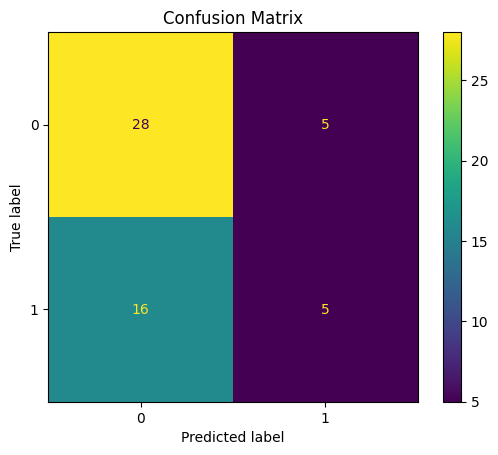

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title('Confusion Matrix')
plt.show()

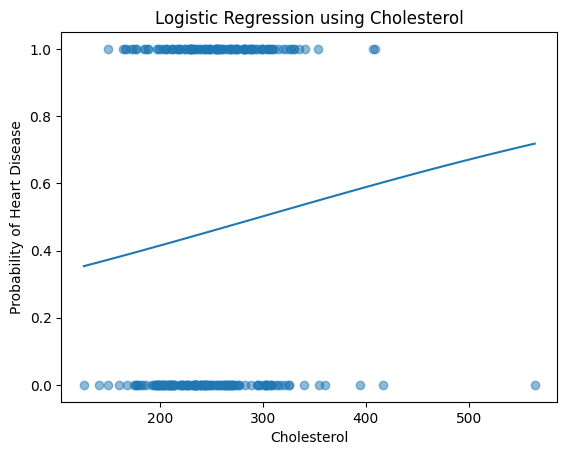

In [ ]:
x_values = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
y_prob = model.predict_proba(x_values)[:,1]

plt.scatter(X, y, alpha=0.5)
plt.plot(x_values, y_prob)

plt.xlabel('Cholesterol')
plt.ylabel('Probability of Heart Disease')
plt.title('Logistic Regression using Cholesterol')
plt.show()

Task 2: Logistic Regression Using Multiple Features

Feature Design


In [ ]:
# selecting all the input features except Heartdisease
a = df.drop('Heart Disease',axis=1)
b = df['Heart Disease']
     

In [ ]:
a = pd.get_dummies(a,drop_first=True)

In [ ]:


from sklearn.model_selection import train_test_split
a_train, a_test, b_train, b_test = train_test_split(a, b, test_size=0.2, random_state=42)

In [ ]:
# feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
a_train_scaled = scaler.fit_transform(a_train)
a_test_scaled = scaler.transform(a_test)

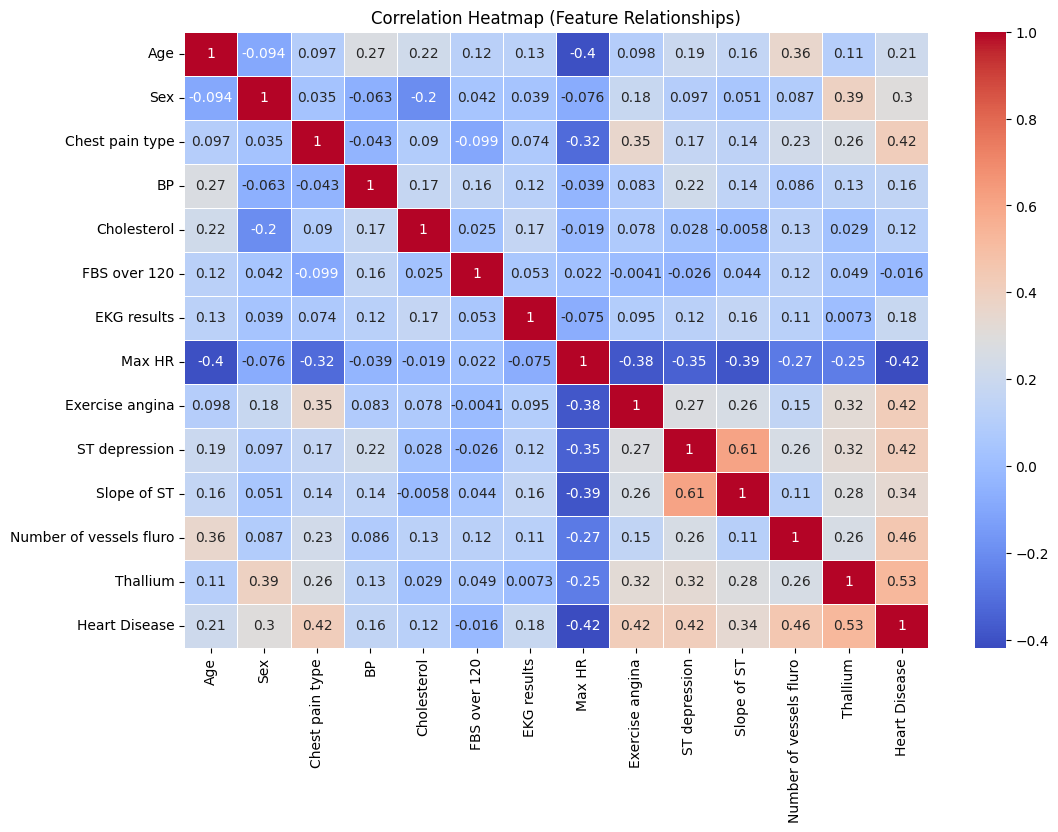

In [ ]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Correlation Heatmap (Feature Relationships)")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
model2 = LogisticRegression()
model2.fit(a_train_scaled,b_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [ ]:
print(model2.intercept_)
print(model2.coef_)

[-0.18493589]
[[-0.08218549  0.63166631  0.63652831  0.43342878  0.28542299 -0.32372586
   0.06736364 -0.21084443  0.38293737  0.51530731  0.33650724  0.83951667
   0.57015837]]


In [ ]:

b_pred = model2.predict(a_test_scaled)
b_pred

array([1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1])

In [ ]:


from sklearn.metrics import (accuracy_score, precision_score, recall_score,
f1_score, confusion_matrix, classification_report)

In [ ]:
print("Accuracy :", accuracy_score(b_test, b_pred))
print("Precision:", precision_score(b_test, b_pred))
print("Recall   :", recall_score(b_test, b_pred))
print("F1 Score :", f1_score(b_test, b_pred))

Accuracy : 0.9074074074074074
Precision: 0.9
Recall   : 0.8571428571428571
F1 Score : 0.8780487804878049


In [ ]:
print(classification_report(b_test,b_pred))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54



In [ ]:
cm = confusion_matrix(b_test,b_pred)
print(cm)

[[31  2]
 [ 3 18]]


Model Comparison

Two Logistic Regression models were developed to compare the effect of using a single feature versus multiple features for heart disease prediction.

Task 1: Single Feature Model

Input Feature: Cholesterol

Advantages:
Simple and easy to understand.
Fast to train and compute.
Helps to study the effect of cholesterol individually.

Limitations:
Uses only one feature.
Ignores other important health factors.
Lower prediction accuracy.


Task 2: Multiple Feature Model

Input Features: All features except target variable

Advantages:
Uses complete patient information.
Captures relationships between multiple variables.
Gives better accuracy and performance.
More suitable for real-world prediction.

Limitations:
More complex.
Hard to interpret individual feature effects.

Performance Comparison

The multi-feature model performs better because heart disease depends on multiple factors such as age, blood pressure, cholesterol, chest pain type, heart rate, and ECG results. Using all features helps the model learn better patterns compared to using only cholesterol.

Conclusion

The multi-feature Logistic Regression model gives better results than the single-feature model. This shows that heart disease prediction is more accurate when multiple medical attributes are used. Therefore, the multi-feature model is more reliable for real-world applications.